In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

import scarf
import scarf.plotting as splt

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
layout = run["umap"]
cell_types = splt.CellField("clusters", label="cell type")
ds

Downloading bucket files: 52931410 / 52931410 complete

Downloading bytes: 52931410 / 52931410 complete

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

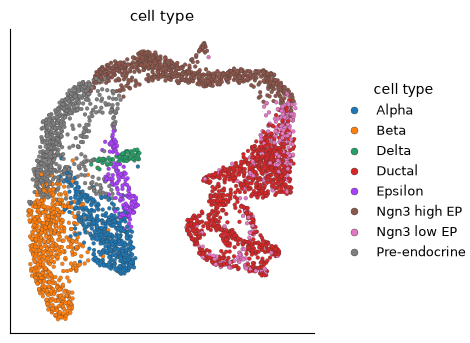

In [2]:
ds.plots.embedding(layout=layout, color_by=cell_types)

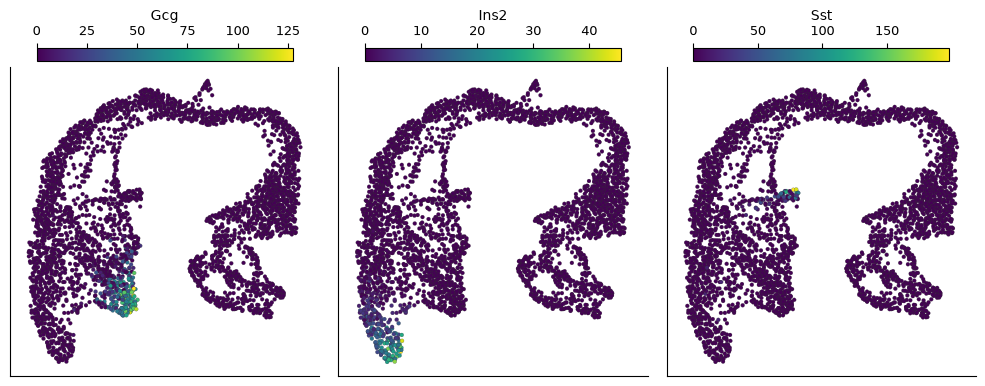

In [3]:
ds.plots.embedding(layout=layout, color_by=["Gcg", "Ins2", "Sst"])

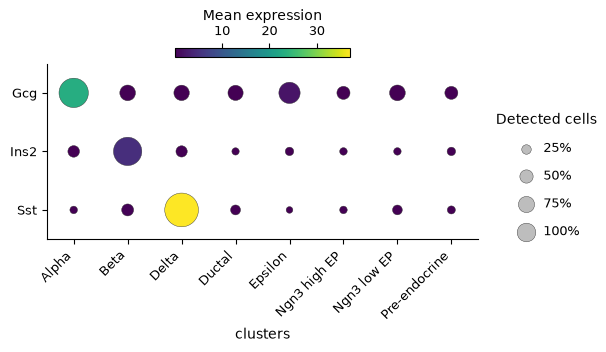

In [4]:
ds.plots.dotplot(
    features=["Gcg", "Ins2", "Sst"],
    group_by="clusters",
)

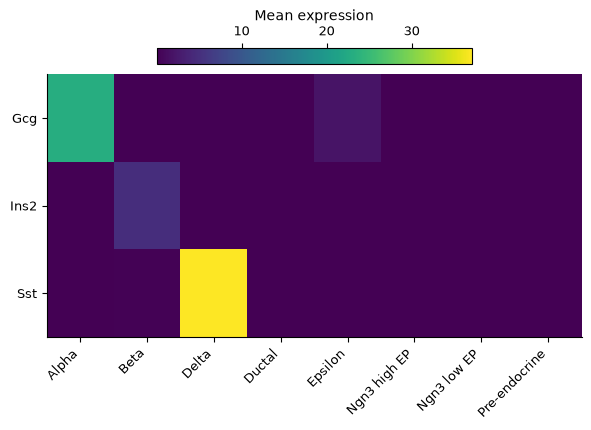

In [5]:
ds.plots.matrixplot(
    features=["Gcg", "Ins2", "Sst"],
    group_by="clusters",
)

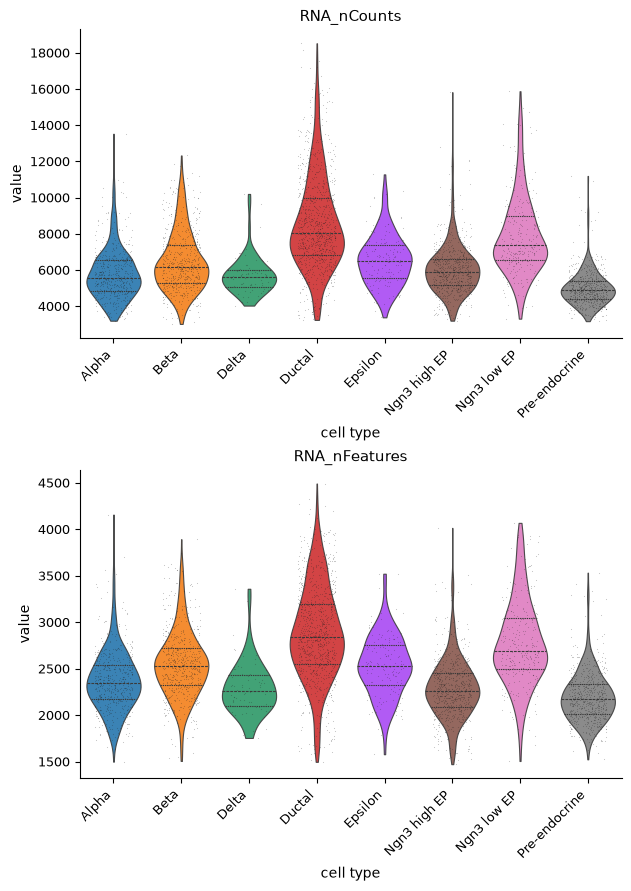

In [6]:
ds.plots.distribution(
    keys=["RNA_nCounts", "RNA_nFeatures"],
    grouping=cell_types,
)

In [7]:
output_directory = Path("figures")
output_directory.mkdir(exist_ok=True)

result = ds.plots.embedding(layout=layout, color_by=cell_types, show=False)
figure_path = output_directory / "pancreas_cell_types.png"
result.save(figure_path)
result.close()
{"file": str(figure_path), "bytes": figure_path.stat().st_size}

{'file': 'figures/pancreas_cell_types.png', 'bytes': 187463}

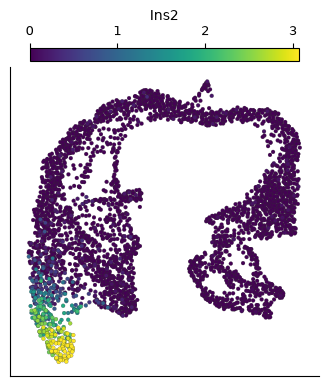

In [8]:
ds.plots.embedding(
    layout=layout,
    color_by="Ins2",
    normalization=splt.NormalizationSpec(transform="log1p"),
    sort_values=True,
    color_scale=splt.ColorScale(quantiles=(0.0, 0.99)),
)

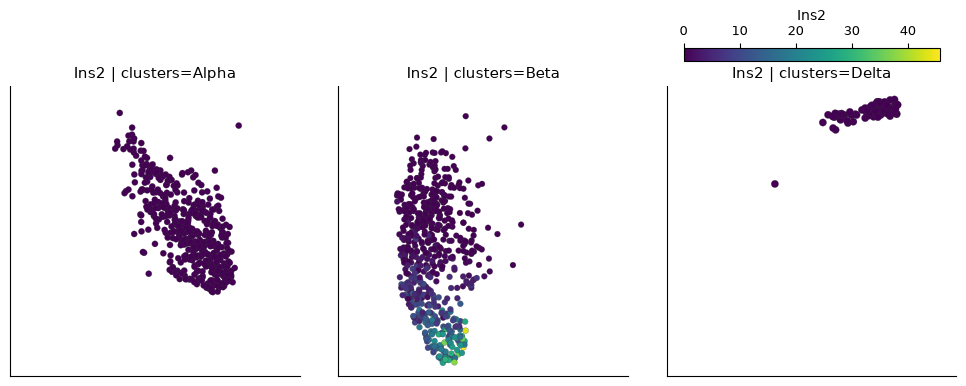

In [9]:
ds.plots.embedding(
    layout=layout,
    color_by="Ins2",
    facet_by=cell_types.key,
    groups=["Alpha", "Beta", "Delta"],
)

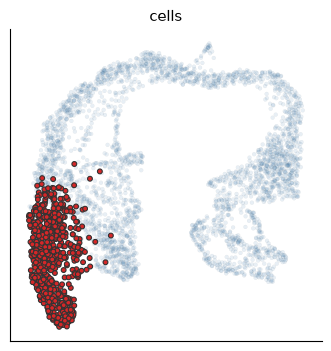

In [10]:
ds.plots.embedding(
    layout=layout,
    color_by=None,
    highlight=splt.Highlight(by=cell_types.key, groups=("Beta",)),
)

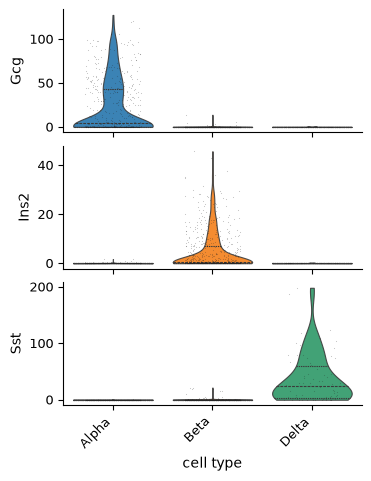

In [11]:
ds.plots.distribution(
    keys=["Gcg", "Ins2", "Sst"],
    grouping=cell_types,
    groups=["Alpha", "Beta", "Delta"],
    kind="stacked_violin",
)

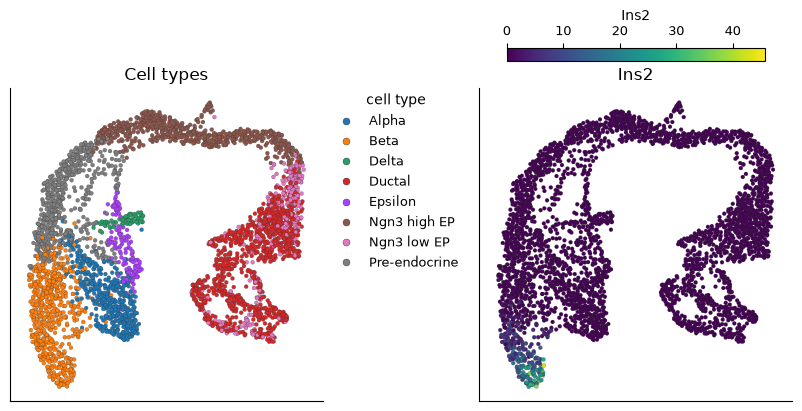

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
for axis, field, title in zip(
    axes, (cell_types, "Ins2"), ("Cell types", "Ins2"), strict=True
):
    ds.plots.embedding(
        layout=layout,
        color_by=field,
        target=axis,
        show_titles=False,
        show=False,
    )
    axis.set_title(title)
figure

In [13]:
panel_path = output_directory / "pancreas_panels.pdf"
figure.savefig(panel_path)
plt.close(figure)
{"file": str(panel_path), "bytes": panel_path.stat().st_size}

{'file': 'figures/pancreas_panels.pdf', 'bytes': 1302888}

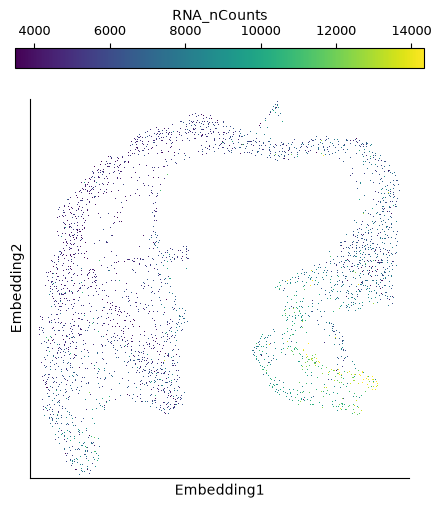

In [14]:
ds.plots.embedding_raster(layout=layout, color_by="RNA_nCounts")